# Universe method

by Reece Colclough and Oleg Glotov

In [102]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sbn

#used to check for stationarity in the time series
from statsmodels.tsa.stattools import adfuller, kpss
from scipy.stats import linregress

# ignore warnings for the KPSS test 
import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.simplefilter('ignore', InterpolationWarning)

In order to find the best stationarity pair, we need to utilize both the ADF test and the KPSS test. Both tests have their drawback and potential issue, therefore, a pair of stocks that performs well in both tests are likely to be more stationary. We construct this test statistic in the following way:
$$\text{Stationarity Score} = - \text{KPSS Stats} - \text{ADF Test}$$
since a low KPSS stats and a low ADF stats both indicates stronger evidence of stationarity (how we weight these two stats is subjective to improvement)

In [103]:
def check_stationarity(series, alpha):

    # h_0 is that the series has a unit root-> if so, likely non-stationarity
    result_adf = adfuller(series,regression='ct')
    p_val = result_adf[1]
    if p_val < alpha:
        # reject, likely trend stationary
        print("ADF test: p-val=", p_val, "-> Conclusion: likely trend stationary")
    else:
        print("ADF test: p-val=", p_val, "-> Conclusion: likely non-stationarity")

    #return result_adf[1]

     #print("----------------------------------------------------------------")
    
    # Since we are focusing on the trend stationarity, we will use the KPSS test
    result_kpss = kpss(series, regression='ct')
    kpss_stat = result_kpss[0]
    p_val = result_kpss[1]
    if p_val > alpha:
        #reject, likely stationary
        print("KPSS test: KPSS stats:", kpss_stat, "p-val=", p_val, "-> Conclusion: likely trend stationary")
    else:
        print("KPSS test: KPSS stats:", kpss_stat, "p-val=", p_val, "-> Conclusion: likely not trend stationary")
    
    station_score = -kpss_stat - result_adf[0]
    return station_score


In [104]:
def methodology_cointegration(stk1, stk2):
    diff = abs(stk1["Close"] - stk2["Close"])

    time = np.arange(len(diff))
    reg = linregress(time, diff)
    #line = reg.intercept + reg.slope*time
    #new_series = diff - line

    return check_stationarity(diff, 0.05), reg.slope


def methodology(stk1, stk2):
    # Calculate correlation between the two stocks' adjusted close prices
    correlation = np.corrcoef(stk1["Close"], stk2["Close"])[0,1]
    
    # Calculate the slope between the two stocks
    time = np.arange(len(stk1["Close"]))
    reg = linregress(time, stk2["Close"] - stk1["Close"])
    
    return correlation, reg.slope

In [105]:
def download_data(stk):

    # start date because of moderna listing in 2018 December and yfinance data delay

    start_date = "2024-01-16"
    end_date = "2025-01-15"

    stk_data = yf.download(stk,start=start_date,end=end_date)

    # fix
    stk_data.columns = stk_data.columns.get_level_values(0)

    return stk_data

In [106]:
# Will plot 2 equities

# universe = ["MSFT", "MRNA",]

# stk_data = []
# for stk in universe:
#     stk_data.append(download_data(stk))

# plt.figure()
# for x in stk_data:
#     plt.plot(x["Close"], label="stk1")

# plt.legend()
# plt.title("stks Price Plot")
# plt.show()

In [107]:
# Download Data

# universe = ["AAPL","AAL","AMD","AMZN","BA","BABA","BAC","C","CAT","COST","CSCO","CVX","DIS","DLR","EQIX","F","GM","GOOGL","GS","IBM","INTC","JNJ","JPM","KO","LMT","LULU","META","MPC","MRK","MRNA","MSFT","MU","NFLX","NKE","NVDA","PFE","TSLA","VZ","WFC","WM","XOM","SCHW","RIOT",]

# Kayden ask
# universe = ["^VIX", "LNF.TO", "TGT", "ANET", "BLDR", "EQT", "TLT", "GC=F", "HG=F", "CL=F", "NKE", "^GSPTSE" , "CADUSD=X", "^TNX", "XBB.TO", "ACO-X.TO", "WFG.TO","HBM.TO","CSH-UN.TO","L.TO","AGG","SPY","SPSB","CG","APO","AER","MA","AMSF","MP","DOLE","AAPL","EA","AMAT","VEEV","TMUS","GSL","TEX","CEG","WSC","ISRG","BLBD" ]

# test
universe = ["AAPL","AAL","AMD","AMZN","BA","BABA","BAC"]

stk_data = []
for stk in universe:
    stk_data.append(download_data(stk))

# Align all dataframes on their index
aligned_data = []
for df in stk_data:
    # Reset index to make date a column
    df_reset = df.reset_index()
    aligned_data.append(df_reset)

# Find common dates across all dataframes
common_dates = set(aligned_data[0]['Date'])
for df in aligned_data[1:]:
    common_dates = common_dates.intersection(set(df['Date']))

# Filter each dataframe to only include common dates
filtered_data = []
for df in aligned_data:
    filtered = df[df['Date'].isin(common_dates)].sort_values('Date').set_index('Date')
    filtered_data.append(filtered)

stk_data = filtered_data  # Replace original data with aligned data

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [108]:
# normalize the stock price for all the stocks so that the first date's price is 1

for i in range(len(stk_data)):
    stk_data[i]["Close"] = stk_data[i]["Close"]/stk_data[i]["Close"][0]

/var/folders/ty/5gy6m3k52ps97ms9_x3glvnh0000gn/T/ipykernel_48566/3837039736.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  stk_data[i]["Close"] = stk_data[i]["Close"]/stk_data[i]["Close"][0]


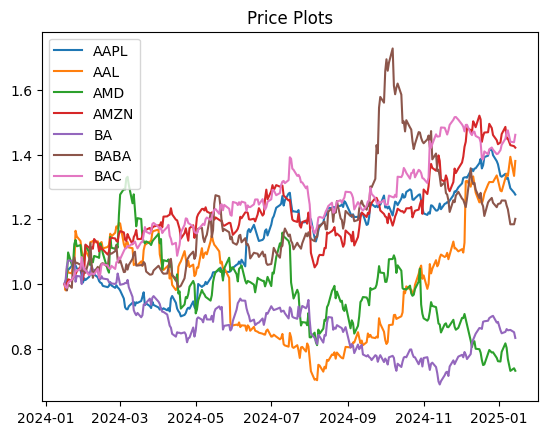

In [109]:
plt.figure()
i = 0
for x in stk_data[:10]:
    plt.plot(x["Close"], label=universe[i])
    i+=1

plt.legend()
plt.title("Price Plots")
plt.savefig('Stock Prices.png', dpi = 1500)
# plt.show()

In [110]:
# initialize cov-matrix
data = np.random.rand(len(universe), len(universe))
slope = np.random.rand(len(universe), len(universe))
stockNum = len(universe)


# Calculate the stationary properties
cov = np.zeros((stockNum, stockNum))
for i in range(stockNum):
    for j in range(stockNum):
        if (i == j):
            data[i,j] = 1
            # set the slope to 0 if the stock is the same
            slope[i,j] = 0
        else:
            print(universe[i]+universe[j])
            
            data[i,j],slope[i,j] = methodology(stk_data[i],stk_data[j])

AAPLAAL
AAPLAMD
AAPLAMZN
AAPLBA
AAPLBABA
AAPLBAC
AALAAPL
AALAMD
AALAMZN
AALBA
AALBABA
AALBAC
AMDAAPL
AMDAAL
AMDAMZN
AMDBA
AMDBABA
AMDBAC
AMZNAAPL
AMZNAAL
AMZNAMD
AMZNBA
AMZNBABA
AMZNBAC
BAAAPL
BAAAL
BAAMD
BAAMZN
BABABA
BABAC
BABAAAPL
BABAAAL
BABAAMD
BABAAMZN
BABABA
BABABAC
BACAAPL
BACAAL
BACAMD
BACAMZN
BACBA
BACBABA


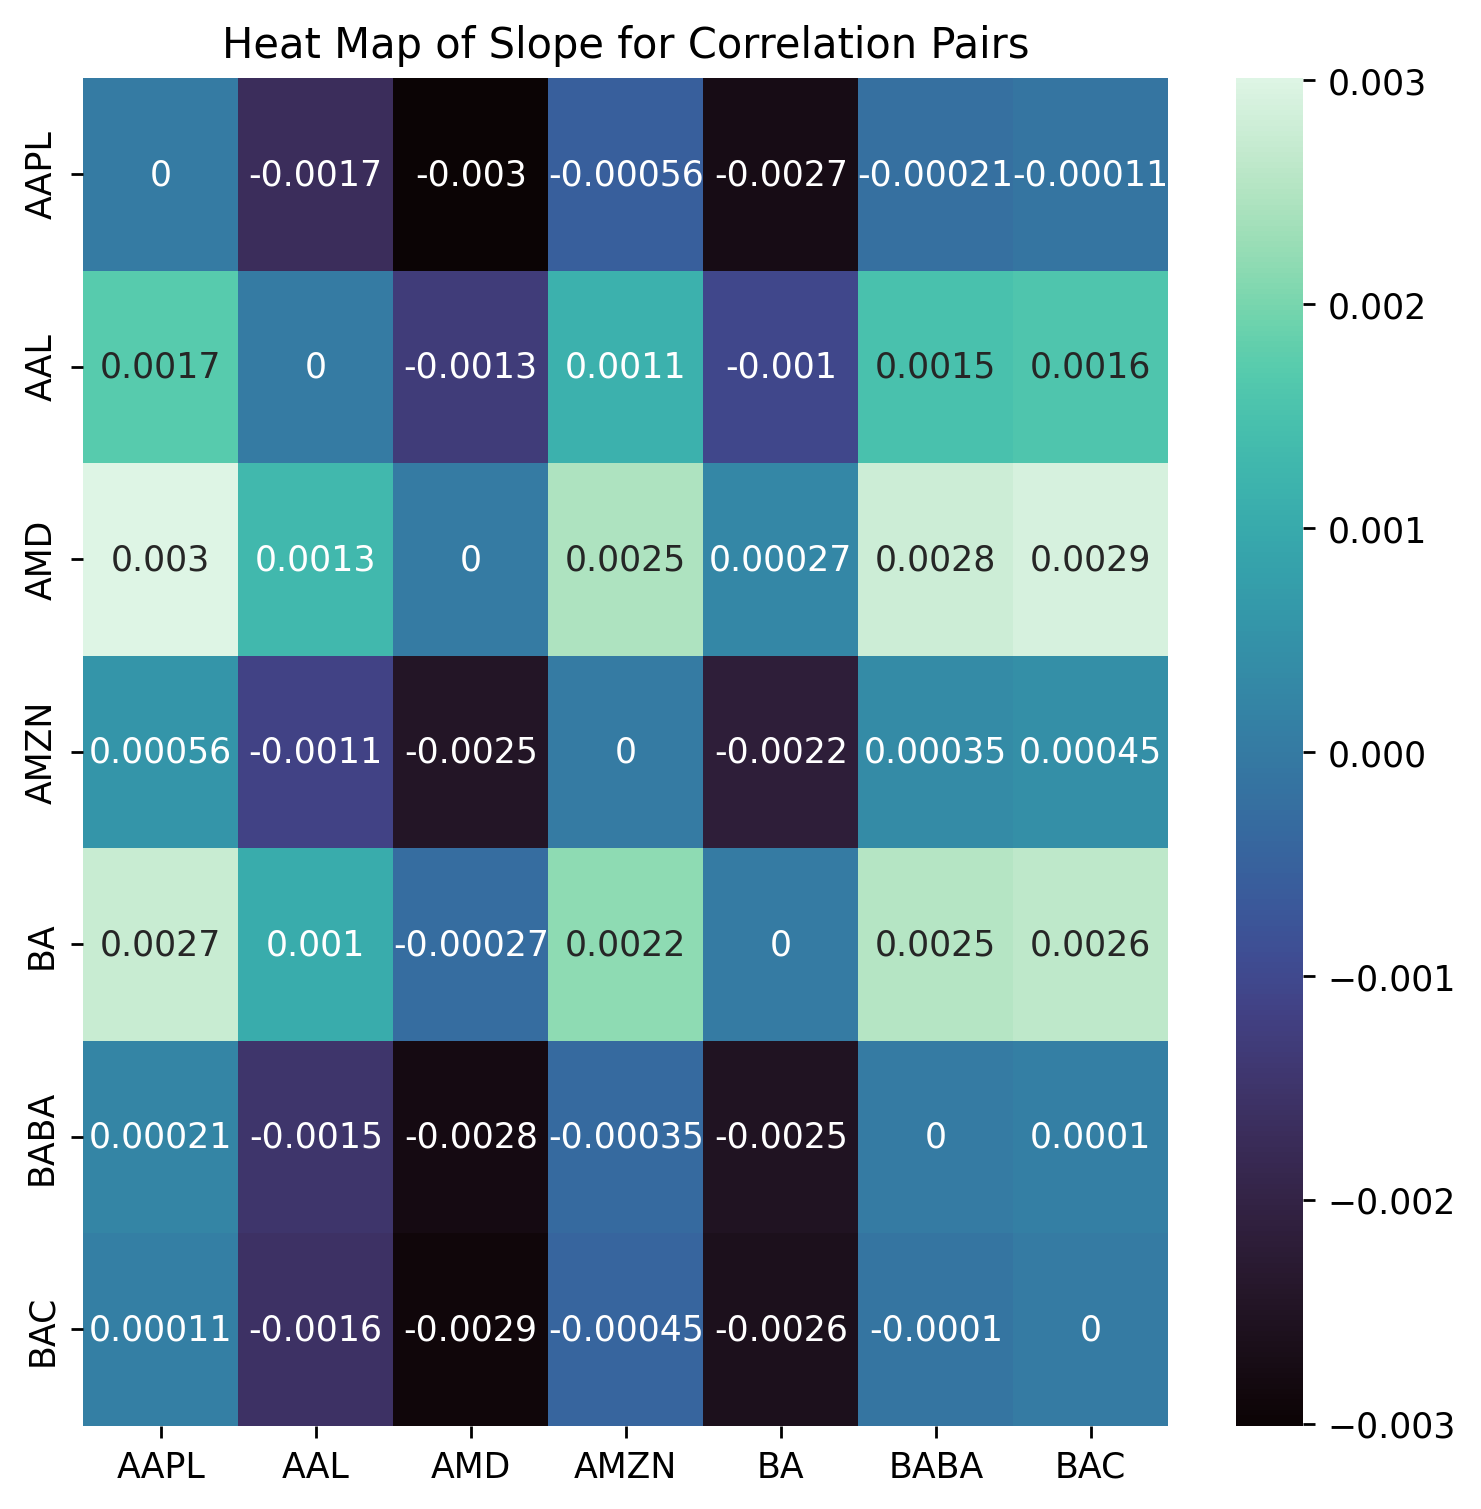

In [111]:
# Create a heatmap of slope using Matplotlib
plt.figure(figsize=(stockNum, stockNum),dpi=250)
heat_map_slope = sbn.heatmap(slope, xticklabels=universe, yticklabels=universe, annot=True, cmap="mako")
plt.title("Heat Map of Slope for Correlation Pairs")

plt.savefig('HeatMap_Correlation_slope.png')
plt.show()

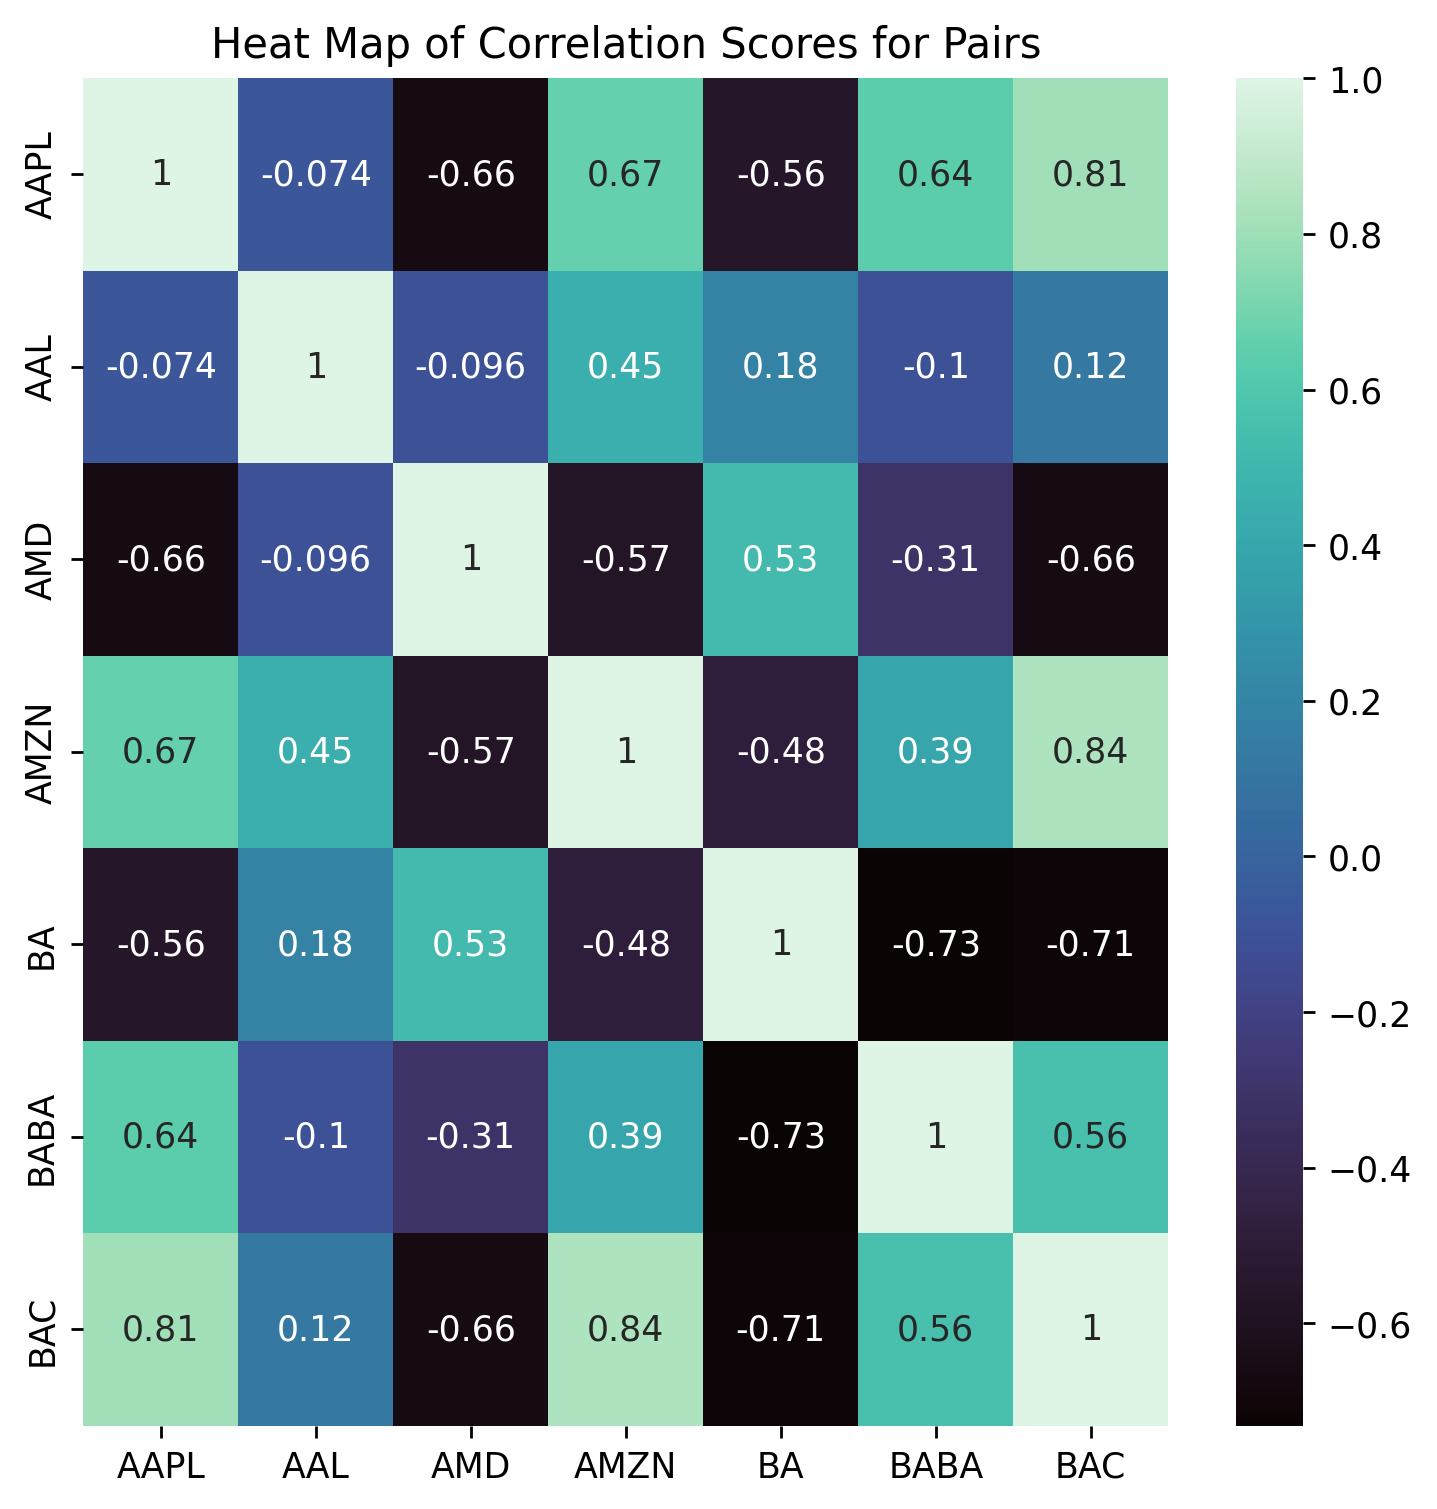

In [112]:
# Create a heatmap using Matplotlib
plt.figure(figsize=(stockNum, stockNum),dpi=250)
heat_map = sbn.heatmap(data, xticklabels=universe, yticklabels=universe, annot=True, cmap="mako")
plt.title("Heat Map of Correlation Scores for Pairs")

plt.savefig('HeatMap_Correlation_score.png')
plt.show()

In [113]:
df = pd.DataFrame(data = data)
df.columns = universe

print("Data Frame")
print(df)
print()

# Get data below diagonal and sort
sol = (df.where(np.triu(np.ones(df.shape), k=1).astype(bool)).stack().sort_values(ascending=False).reset_index())

mapping = {i: universe[i] for i in range(len(universe))}

# Replace numbers in column 'A' with the corresponding index string
sol['level_0'] = sol['level_0'].map(mapping)

Data Frame
       AAPL       AAL       AMD      AMZN        BA      BABA       BAC
0  1.000000 -0.074423 -0.662256  0.665704 -0.558853  0.639848  0.807701
1 -0.074423  1.000000 -0.095977  0.452234  0.178327 -0.099922  0.123452
2 -0.662256 -0.095977  1.000000 -0.569401  0.525414 -0.310529 -0.662583
3  0.665704  0.452234 -0.569401  1.000000 -0.484374  0.393675  0.842871
4 -0.558853  0.178327  0.525414 -0.484374  1.000000 -0.731379 -0.712589
5  0.639848 -0.099922 -0.310529  0.393675 -0.731379  1.000000  0.556443
6  0.807701  0.123452 -0.662583  0.842871 -0.712589  0.556443  1.000000



In [114]:
print(sol.head(15))
print()
n = 15
print(f"last {n} rows")
print()
print(sol.tail(n))

   level_0 level_1         0
0     AMZN     BAC  0.842871
1     AAPL     BAC  0.807701
2     AAPL    AMZN  0.665704
3     AAPL    BABA  0.639848
4     BABA     BAC  0.556443
5      AMD      BA  0.525414
6      AAL    AMZN  0.452234
7     AMZN    BABA  0.393675
8      AAL      BA  0.178327
9      AAL     BAC  0.123452
10    AAPL     AAL -0.074423
11     AAL     AMD -0.095977
12     AAL    BABA -0.099922
13     AMD    BABA -0.310529
14    AMZN      BA -0.484374

last 15 rows

   level_0 level_1         0
6      AAL    AMZN  0.452234
7     AMZN    BABA  0.393675
8      AAL      BA  0.178327
9      AAL     BAC  0.123452
10    AAPL     AAL -0.074423
11     AAL     AMD -0.095977
12     AAL    BABA -0.099922
13     AMD    BABA -0.310529
14    AMZN      BA -0.484374
15    AAPL      BA -0.558853
16     AMD    AMZN -0.569401
17    AAPL     AMD -0.662256
18     AMD     BAC -0.662583
19      BA     BAC -0.712589
20      BA    BABA -0.731379


In [115]:
# add a new column to the dataframe
sol['slope'] = sol.apply(lambda row: slope[universe.index(row['level_0'])][universe.index(row['level_1'])], axis=1)
sol.columns = ['Stock 1', 'Stock 2', 'Correlation', 'Slope']
# display the top 30 pairs with positive slope
print()
print("Top 30 Pairs with Positive Slope")
print()
print(sol[sol['Slope'] > 0].head(30))


Top 30 Pairs with Positive Slope

   Stock 1 Stock 2  Correlation     Slope
0     AMZN     BAC     0.842871  0.000446
4     BABA     BAC     0.556443  0.000100
5      AMD      BA     0.525414  0.000274
6      AAL    AMZN     0.452234  0.001135
7     AMZN    BABA     0.393675  0.000346
9      AAL     BAC     0.123452  0.001582
12     AAL    BABA    -0.099922  0.001481
13     AMD    BABA    -0.310529  0.002797
16     AMD    AMZN    -0.569401  0.002451
18     AMD     BAC    -0.662583  0.002897
19      BA     BAC    -0.712589  0.002623
20      BA    BABA    -0.731379  0.002523
